Q-Learning

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [3]:
#Environment setup
states = 6
actions = 2

Q = np.zeros((states, actions))

In [4]:
#Hyperparameters
alpha = 0.1      # learning rate
gamma = 0.9      # discount factor
epsilon = 0.2    # exploration rate
episodes = 500

In [5]:
#Reward function (simple rule)
def get_reward(state):
    return 1 if state == states - 1 else 0

In [6]:
#ε-greedy action selection
def choose_action(state):
    if np.random.rand() < epsilon:
        return np.random.randint(actions)
    return np.argmax(Q[state])

In [7]:
#Training loop (Q-Learning core)
rewards = []

for ep in range(episodes):
    state = 0
    total_reward = 0

    while state != states - 1:

        action = choose_action(state)

        # simple transition (move forward)
        next_state = min(state + 1, states - 1)

        reward = get_reward(next_state)
        total_reward += reward

        # 🔥 Q-Learning update rule
        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state

    rewards.append(total_reward)

In [8]:
#Final Q-table
print("Final Q-Table:")
print(Q)

Final Q-Table:
[[0.6561     0.65071221]
 [0.729      0.71786392]
 [0.80298296 0.81      ]
 [0.9        0.89730719]
 [1.         0.99484622]
 [0.         0.        ]]


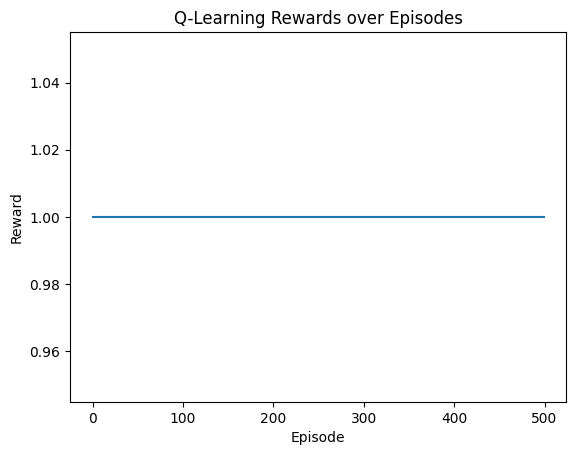

In [9]:
#Plot learning curve
plt.plot(rewards)
plt.title("Q-Learning Rewards over Episodes")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()